<a href="https://colab.research.google.com/github/piatekwmarcu/Advanced_algorithms_and_data_structures/blob/main/lab5_MAIN_FILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [ ]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [ ]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [ ]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [ ]:
df.show()

26/05/16 01:57:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [ ]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [ ]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [ ]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [ ]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka


+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [ ]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [ ]:
df.createOrReplaceTempView("cars")

In [ ]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [ ]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [ ]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [ ]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


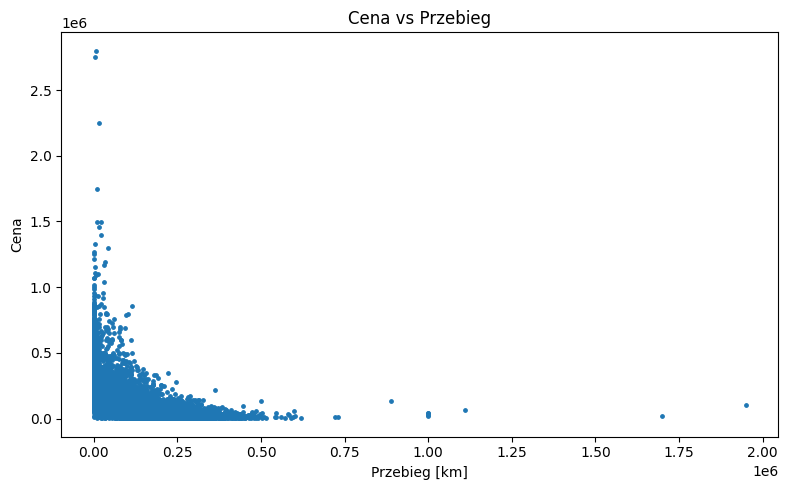

In [ ]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [1]:
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!pip install pyspark -q

In [2]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, year, hour, udf
from pyspark.sql.types import StringType
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("Chicago Crimes Analysis") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

df_crimes = spark.read.option("header", True) \
    .option("inferSchema", True) \
    .csv("chicago_crimes_sample.csv")

df_crimes.show(5)
df_crimes.printSchema()

+-------------+--------------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|           id|   case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|
+-------------+--------------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|     14193193|      JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...|0820|       THEFT|      $500 AND UNDER|              STREET| false|   false| 811|       8|  13|

In [5]:
print("Kolumny w pliku:")
print(df_crimes.columns)

print("Liczba wierszy przed czyszczeniem:", df_crimes.count())

df_crimes_clean = df_crimes.dropDuplicates()

df_crimes_clean = df_crimes_clean.dropna(
    subset=["date", "primary_type", "latitude", "longitude"]
)

print("Liczba wierszy po czyszczeniu:", df_crimes_clean.count())

df_crimes_clean.show(5)

Kolumny w pliku:
['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']
Liczba wierszy przed czyszczeniem: 149848
Liczba wierszy po czyszczeniu: 49924
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|      id|case_number|               date|               block|iucr|        primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|
+--------+-----------+-------------------+--------------------+----+-------

In [6]:
df_crimes_clean = df_crimes_clean.withColumn(
    "DateTime",
    to_timestamp(col("date"), "MM/dd/yyyy hh:mm:ss a")
)

def get_time_of_day(hour_value):
    if hour_value is None:
        return "Unknown"
    elif 5 <= hour_value < 12:
        return "Morning"
    elif 12 <= hour_value < 18:
        return "Afternoon"
    elif 18 <= hour_value < 22:
        return "Evening"
    else:
        return "Night"

time_of_day_udf = udf(get_time_of_day, StringType())

df_crimes_clean = df_crimes_clean.withColumn("Hour", hour(col("DateTime")))
df_crimes_clean = df_crimes_clean.withColumn("TimeOfDay", time_of_day_udf(col("Hour")))

df_crimes_clean.select("date", "DateTime", "Hour", "TimeOfDay").show(10, truncate=False)

+-------------------+-------------------+----+---------+
|date               |DateTime           |Hour|TimeOfDay|
+-------------------+-------------------+----+---------+
|2026-05-06 23:15:00|2026-05-06 23:15:00|23  |Night    |
|2026-05-06 23:10:00|2026-05-06 23:10:00|23  |Night    |
|2026-05-06 23:09:00|2026-05-06 23:09:00|23  |Night    |
|2026-05-06 23:07:00|2026-05-06 23:07:00|23  |Night    |
|2026-05-06 23:00:00|2026-05-06 23:00:00|23  |Night    |
|2026-05-06 23:00:00|2026-05-06 23:00:00|23  |Night    |
|2026-05-06 23:00:00|2026-05-06 23:00:00|23  |Night    |
|2026-05-06 22:44:00|2026-05-06 22:44:00|22  |Night    |
|2026-05-06 22:36:00|2026-05-06 22:36:00|22  |Night    |
|2026-05-06 22:31:00|2026-05-06 22:31:00|22  |Night    |
+-------------------+-------------------+----+---------+
only showing top 10 rows


In [7]:
from pyspark.sql.functions import year

df_crimes_clean = df_crimes_clean.withColumn("Year", year(col("DateTime")))

df_crimes_clean.cache()

df_crimes_clean.write \
    .mode("overwrite") \
    .partitionBy("Year") \
    .parquet("chicago_crimes_parquet")

print("Dane zostały zapisane do formatu Parquet z partycjonowaniem po roku.")

Dane zostały zapisane do formatu Parquet z partycjonowaniem po roku.


In [8]:
df_parquet = spark.read.parquet("chicago_crimes_parquet")

df_parquet.show(5)
df_parquet.printSchema()

+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+-------------------+------------+-------------+--------+-------------------+----+---------+----+
|      id|case_number|               date|               block|iucr|        primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|         updated_on|    latitude|    longitude|location|           DateTime|Hour|TimeOfDay|Year|
+--------+-----------+-------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+-------------------+------------+-------------+--------+-------------------+----+---------+----+
|14189355|   JK244986|2026-05-06 23:15:00| 047XX S DREXEL BLV

In [9]:
crimes_by_type = df_parquet.groupBy("primary_type") \
    .count() \
    .orderBy(col("count").desc())

crimes_by_type.show(10)

+-------------------+-----+
|       primary_type|count|
+-------------------+-----+
|              THEFT|10895|
|            BATTERY| 9250|
|    CRIMINAL DAMAGE| 5493|
|            ASSAULT| 4561|
|MOTOR VEHICLE THEFT| 3882|
|      OTHER OFFENSE| 3454|
|           BURGLARY| 3158|
| DECEPTIVE PRACTICE| 2664|
|          NARCOTICS| 1455|
|  CRIMINAL TRESPASS| 1190|
+-------------------+-----+
only showing top 10 rows


In [10]:
crimes_by_time = df_parquet.groupBy("TimeOfDay") \
    .count() \
    .orderBy(col("count").desc())

crimes_by_time.show()

+---------+-----+
|TimeOfDay|count|
+---------+-----+
|Afternoon|16104|
|    Night|12164|
|  Morning|11593|
|  Evening|10063|
+---------+-----+



In [11]:
crimes_by_year = df_parquet.groupBy("Year") \
    .count() \
    .orderBy("Year")

crimes_by_year.show()

+----+-----+
|Year|count|
+----+-----+
|2026|49924|
+----+-----+



In [12]:
arrest_stats = df_parquet.groupBy("arrest") \
    .count() \
    .orderBy(col("count").desc())

arrest_stats.show()

+------+-----+
|arrest|count|
+------+-----+
| false|42519|
|  true| 7405|
+------+-----+



In [13]:
crimes_by_type.explain(True)

== Parsed Logical Plan ==
'Sort ['count DESC NULLS LAST], true
+- Aggregate [primary_type#1012], [primary_type#1012, count(1) AS count#1109L]
   +- Relation [id#1007,case_number#1008,date#1009,block#1010,iucr#1011,primary_type#1012,description#1013,location_description#1014,arrest#1015,domestic#1016,beat#1017,district#1018,ward#1019,community_area#1020,fbi_code#1021,x_coordinate#1022,y_coordinate#1023,updated_on#1024,latitude#1025,longitude#1026,location#1027,DateTime#1028,Hour#1029,TimeOfDay#1030,Year#1031] parquet

== Analyzed Logical Plan ==
primary_type: string, count: bigint
Sort [count#1109L DESC NULLS LAST], true
+- Aggregate [primary_type#1012], [primary_type#1012, count(1) AS count#1109L]
   +- Relation [id#1007,case_number#1008,date#1009,block#1010,iucr#1011,primary_type#1012,description#1013,location_description#1014,arrest#1015,domestic#1016,beat#1017,district#1018,ward#1019,community_area#1020,fbi_code#1021,x_coordinate#1022,y_coordinate#1023,updated_on#1024,latitude#1025,

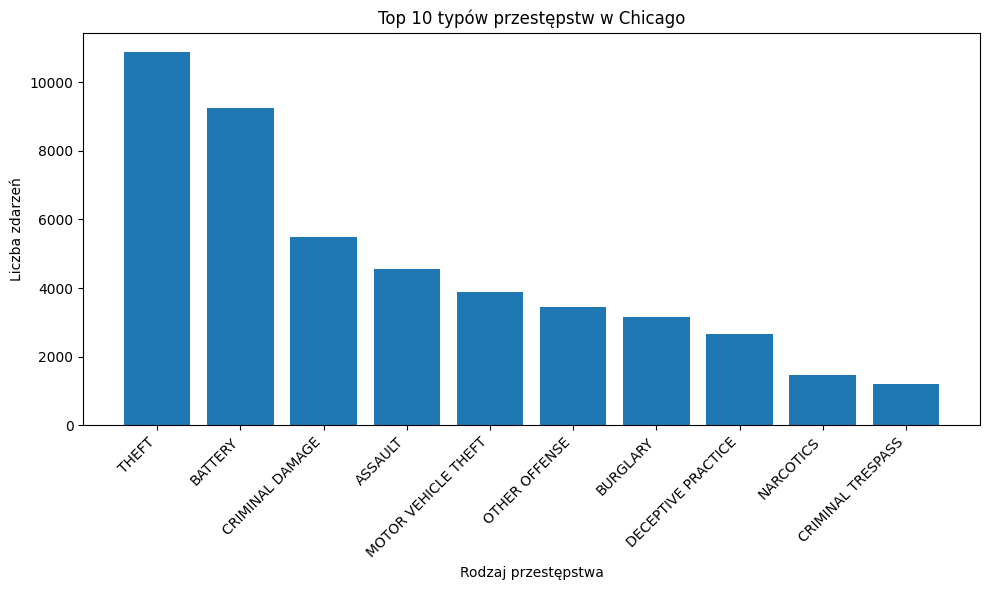

In [14]:
crimes_by_type_pd = crimes_by_type.limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.bar(crimes_by_type_pd["primary_type"], crimes_by_type_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Rodzaj przestępstwa")
plt.ylabel("Liczba zdarzeń")
plt.title("Top 10 typów przestępstw w Chicago")
plt.tight_layout()
plt.show()

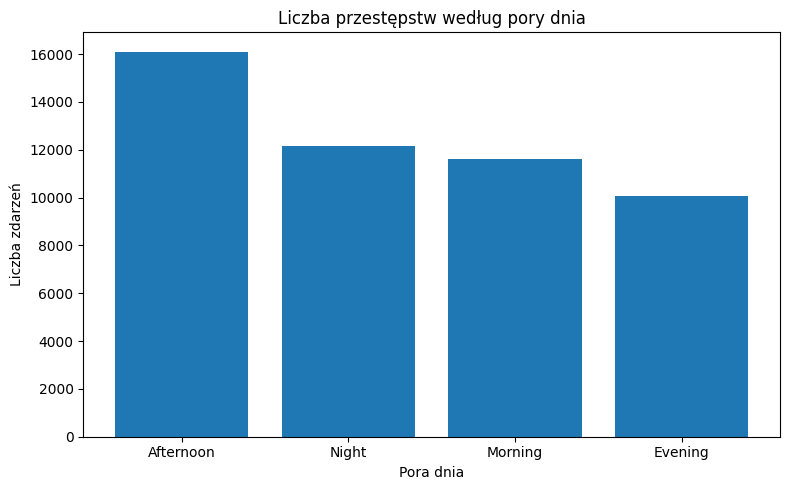

In [15]:
crimes_by_time_pd = crimes_by_time.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(crimes_by_time_pd["TimeOfDay"], crimes_by_time_pd["count"])
plt.xlabel("Pora dnia")
plt.ylabel("Liczba zdarzeń")
plt.title("Liczba przestępstw według pory dnia")
plt.tight_layout()
plt.show()

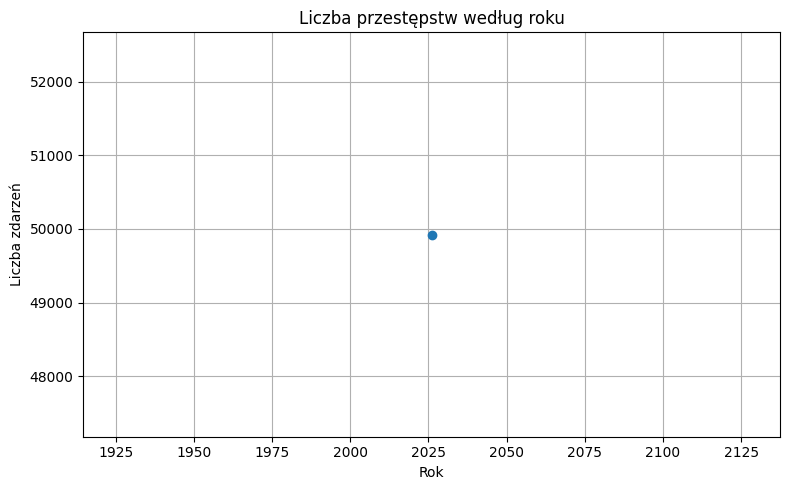

In [16]:
crimes_by_year_pd = crimes_by_year.toPandas()

plt.figure(figsize=(8, 5))
plt.plot(crimes_by_year_pd["Year"], crimes_by_year_pd["count"], marker="o")
plt.xlabel("Rok")
plt.ylabel("Liczba zdarzeń")
plt.title("Liczba przestępstw według roku")
plt.grid(True)
plt.tight_layout()
plt.show()

### Wnioski z analizy

W ramach zadania dane zostały wczytane z pliku `chicago_crimes_sample.csv`, oczyszczone z duplikatów oraz rekordów z brakami w kluczowych kolumnach: `date`, `primary_type`, `latitude` i `longitude`.

Następnie na podstawie kolumny `date` utworzono kolumnę `DateTime`, z której wyodrębniono godzinę zdarzenia. Przy użyciu funkcji UDF dodano nową kolumnę `TimeOfDay`, klasyfikującą zdarzenia do jednej z czterech kategorii: `Morning`, `Afternoon`, `Evening` oraz `Night`.

Dane zostały zoptymalizowane przez użycie `cache()` oraz zapisane do formatu Parquet z partycjonowaniem według roku (`Year`). Format Parquet pozwala na efektywniejsze przechowywanie i szybszy odczyt danych, szczególnie przy większych zbiorach.

W części analitycznej sprawdzono:
- najczęściej występujące typy przestępstw,
- rozkład przestępstw według pory dnia,
- liczbę zdarzeń w poszczególnych latach,
- statystyki dotyczące aresztowań.

Dodatkowo użyto funkcji `.explain(True)`, aby przedstawić plan wykonania zapytania Spark.

In [20]:
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

ml_df = df_parquet.select(
    col("primary_type"),
    col("Hour"),
    col("Year"),
    col("arrest").cast("string").alias("arrest"),
    col("domestic").cast("string").alias("domestic"),
    col("district"),
    col("ward"),
    col("latitude"),
    col("longitude")
).dropna()

ml_df.show(5)
print("Liczba rekordów do modelu:", ml_df.count())

+--------------------+----+----+------+--------+--------+----+------------+-------------+
|        primary_type|Hour|Year|arrest|domestic|district|ward|    latitude|    longitude|
+--------------------+----+----+------+--------+--------+----+------------+-------------+
|PUBLIC PEACE VIOL...|  23|2026|  true|   false|       2|   4|41.808676568|-87.604357357|
|       OTHER OFFENSE|  23|2026| false|   false|      16|  41|41.971180491|-87.789175479|
|             BATTERY|  23|2026|  true|    true|       5|  10|41.653793261|-87.597489018|
|             BATTERY|  23|2026| false|    true|      15|  37|41.893134119| -87.74885684|
|               THEFT|  23|2026| false|   false|      12|  25|41.856486716|-87.642471174|
+--------------------+----+----+------+--------+--------+----+------------+-------------+
only showing top 5 rows
Liczba rekordów do modelu: 49924


In [21]:
label_indexer = StringIndexer(
    inputCol="primary_type",
    outputCol="label",
    handleInvalid="keep"
)

arrest_indexer = StringIndexer(
    inputCol="arrest",
    outputCol="arrest_index",
    handleInvalid="keep"
)

domestic_indexer = StringIndexer(
    inputCol="domestic",
    outputCol="domestic_index",
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[
        "Hour",
        "Year",
        "arrest_index",
        "domestic_index",
        "district",
        "ward",
        "latitude",
        "longitude"
    ],
    outputCol="features",
    handleInvalid="keep"
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20,
    maxDepth=5,
    seed=42
)

In [22]:
train_data, test_data = ml_df.randomSplit([0.8, 0.2], seed=42)

pipeline = Pipeline(stages=[
    label_indexer,
    arrest_indexer,
    domestic_indexer,
    assembler,
    rf
])

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

predictions.select("primary_type", "label", "prediction", "probability").show(10, truncate=False)

+------------+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|primary_type|label|prediction|probability                                                                                                                                                                                                                                                                                                                  

In [23]:
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy = evaluator_accuracy.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print("Accuracy:", round(accuracy, 4))
print("F1-score:", round(f1_score, 4))

Accuracy: 0.3216
F1-score: 0.2007


### Opcjonalna część MLlib — klasyfikacja typu przestępstwa

W ramach części opcjonalnej wykorzystano bibliotekę MLlib do zbudowania prostego modelu klasyfikacyjnego przewidującego typ przestępstwa (`primary_type`). Jako cechy wejściowe wykorzystano m.in. godzinę zdarzenia, rok, informację o aresztowaniu, informację o charakterze domowym zdarzenia, dystrykt, ward oraz współrzędne geograficzne.

Do przygotowania danych wykorzystano:
- `StringIndexer` do zakodowania etykiety oraz zmiennych logicznych,
- `VectorAssembler` do połączenia cech w jeden wektor,
- `RandomForestClassifier` jako model klasyfikacyjny.

Dane zostały podzielone na zbiór treningowy i testowy w proporcji 80/20. Model oceniono za pomocą metryk `accuracy` oraz `F1-score`.

Uzyskane wyniki należy traktować jako orientacyjne, ponieważ typ przestępstwa zależy od wielu czynników, a w modelu wykorzystano jedynie podstawowe cechy dostępne w zbiorze danych. Celem tej części było pokazanie możliwości zastosowania MLlib w zadaniu analizy danych, a nie stworzenie idealnego modelu predykcyjnego.

In [ ]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)
